In [2]:
import pandas as pd
df = pd.read_csv("FlowPay_Manual_Simulation_Result.csv")

print("📊 현재 데이터의 전체 컬럼 목록:")
print(df.columns.tolist())

📊 현재 데이터의 전체 컬럼 목록:
['COMPANY_ID', 'receivable_Total_Amt', 'receivable_Partner_Count', 'Receivable_Concentration', 'BNPL_Req_Count', 'BNPL_Avg_Amt', 'BNPL_Success_Rate', 'LIQUIDITY_RATIO', 'DEBT_RATIO', 'INTEREST_COVERAGE_RATIO', 'OPERATING_MARGIN', 'SALES_GROWTH_RATE', 'BORROWING_DEPENDENCE', 'CASH_RATIO', 'LINKED_PARTNERS', 'NEGATIVE_COMMENT_COUNT', 'UPLOADED_FILE_COUNT', 'EMPLOYEE_COUNT', 'REP_CHANGE_COUNT', 'GROSS_PROFIT_MARGIN', 'NET_PROFIT_MARGIN', 'SALES_REVENUE', 'MANUAL_SCORE', 'MANUAL_GRADE', 'UNDERWRITER_REPORT']


In [4]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

print("🧠 [ML Scoring Engine] AI 기반 예측 점수(ML_FlowScore) 산출 가동...")
print("-" * 90)

# 1. 데이터 로드 (마스터 데이터 & 방금 만든 Y값 타겟 데이터)
master_file = "Final_Integrated_Credit_Master_v5_Income_Added.csv"
target_file = "Target_Candidates_Y.csv"

df_master = pd.read_csv(master_file, dtype={'COMPANY_ID': str})
df_y = pd.read_csv(target_file, dtype={'COMPANY_ID': str})

# COMPANY_ID 기준으로 병합 (순수 연체 Y값만 가져오기)
df = pd.merge(df_master, df_y[['COMPANY_ID', 'Y_Overdue']], on='COMPANY_ID', how='inner')

# 2. X(피처)와 y(타겟) 분리 및 전처리
exclude_cols = ['COMPANY_ID', 'CREDIT_SCORE', 'RISK_GRADE', 'DETECTED_RISKS', 'Y_Overdue']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y = df['Y_Overdue']

# 문자형 데이터 숫자로 강제 변환 및 결측치(NaN) 중앙값 처리
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce')
        
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 3. ML 모델 학습 (실제 부도 11건 집중 학습)
print("▶️ Random Forest 모델 학습 중 (11개 부도 패턴 분석)...")
rf_model = RandomForestClassifier(n_estimators=500, random_state=276, class_weight='balanced')
rf_model.fit(X_imputed, y)

# 4. 🔥 [핵심] 전체 기업에 대한 AI 예측 수행
print("▶️ 전체 1,514개 기업 대상 부도 확률(PD) 및 ML 점수 산출 중...")

# predict_proba는 [정상 확률, 부도 확률] 2개를 뱉음. 우리가 필요한 건 두 번째(부도 확률)
pd_probabilities = rf_model.predict_proba(X_imputed)[:, 1]

# 부도 확률을 백분율(%)로 변환 (예: 0.125 -> 12.5%)
df['ML_PD_RATE'] = np.round(pd_probabilities * 100, 2)

# AI 신용 점수 산출: 100점 만점에서 부도 확률을 뺀 값 (부도 확률이 0%면 100점)
df['ML_FLOW_SCORE'] = 100 - df['ML_PD_RATE']

# AI 등급 부여 (예시: 85점 이상 저위험, 65점 이상 중위험, 그 미만 고위험)
def assign_ml_grade(score):
    if score >= 85: return 'LOW_RISK'
    elif score >= 65: return 'MEDIUM_RISK'
    else: return 'HIGH_RISK'
    
df['ML_RISK_GRADE'] = df['ML_FLOW_SCORE'].apply(assign_ml_grade)

# 5. 최종 결과 저장
output_cols = ['COMPANY_ID', 'Y_Overdue', 'ML_FLOW_SCORE', 'ML_RISK_GRADE', 'ML_PD_RATE'] + feature_cols
result_df = df[output_cols].sort_values(by='ML_FLOW_SCORE') # 위험한 순서대로 정렬

output_filename = "FlowPay_ML_Predicted_Scores.csv"
result_df.to_csv(output_filename, index=False)

print("\n🎉 [산출 완료] 성공적으로 ML 예측이 끝났습니다!")
print("=" * 70)
print(f"📊 저장된 파일명: {output_filename}")
print(result_df[['COMPANY_ID', 'ML_FLOW_SCORE', 'ML_RISK_GRADE', 'ML_PD_RATE', 'Y_Overdue']].head(10).to_string(index=False))
print("=" * 70)
print("💡 위 목록은 AI가 판별한 '가장 위험한(점수가 낮은) 기업 Top 10'입니다.")

🧠 [ML Scoring Engine] AI 기반 예측 점수(ML_FlowScore) 산출 가동...
------------------------------------------------------------------------------------------
▶️ Random Forest 모델 학습 중 (11개 부도 패턴 분석)...
▶️ 전체 1,514개 기업 대상 부도 확률(PD) 및 ML 점수 산출 중...

🎉 [산출 완료] 성공적으로 ML 예측이 끝났습니다!
📊 저장된 파일명: FlowPay_ML_Predicted_Scores.csv
COMPANY_ID  ML_FLOW_SCORE ML_RISK_GRADE  ML_PD_RATE  Y_Overdue
0000000072          23.94     HIGH_RISK       76.06          0
0000000079          23.94     HIGH_RISK       76.06          0
0000000620          23.94     HIGH_RISK       76.06          0
0000000558          23.94     HIGH_RISK       76.06          0
0000000557          23.94     HIGH_RISK       76.06          0
0000000621          23.94     HIGH_RISK       76.06          0
0000000611          23.94     HIGH_RISK       76.06          0
0000000091          23.94     HIGH_RISK       76.06          0
0000000100          23.94     HIGH_RISK       76.06          0
0000000101          23.94     HIGH_RISK       76.06         

🔍 [Feature Validation] 'LINKED_PARTNERS(거래처 수)'와 '연체(Default)'의 상관관계 검증

📊 [통계 요약] 정상(0) vs 연체(1) 기업의 거래처 수 비교
            count      mean  50%  min    max
Y_Overdue                                   
0          1503.0  2.449102  1.0  0.0  657.0
1            11.0  2.090909  2.0  0.0    4.0


C:\Users\cozy1\AppData\Local\Temp\ipykernel_21360\1879786421.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Y_Overdue', y='LINKED_PARTNERS', data=df, ax=axes[0], palette='Set2')


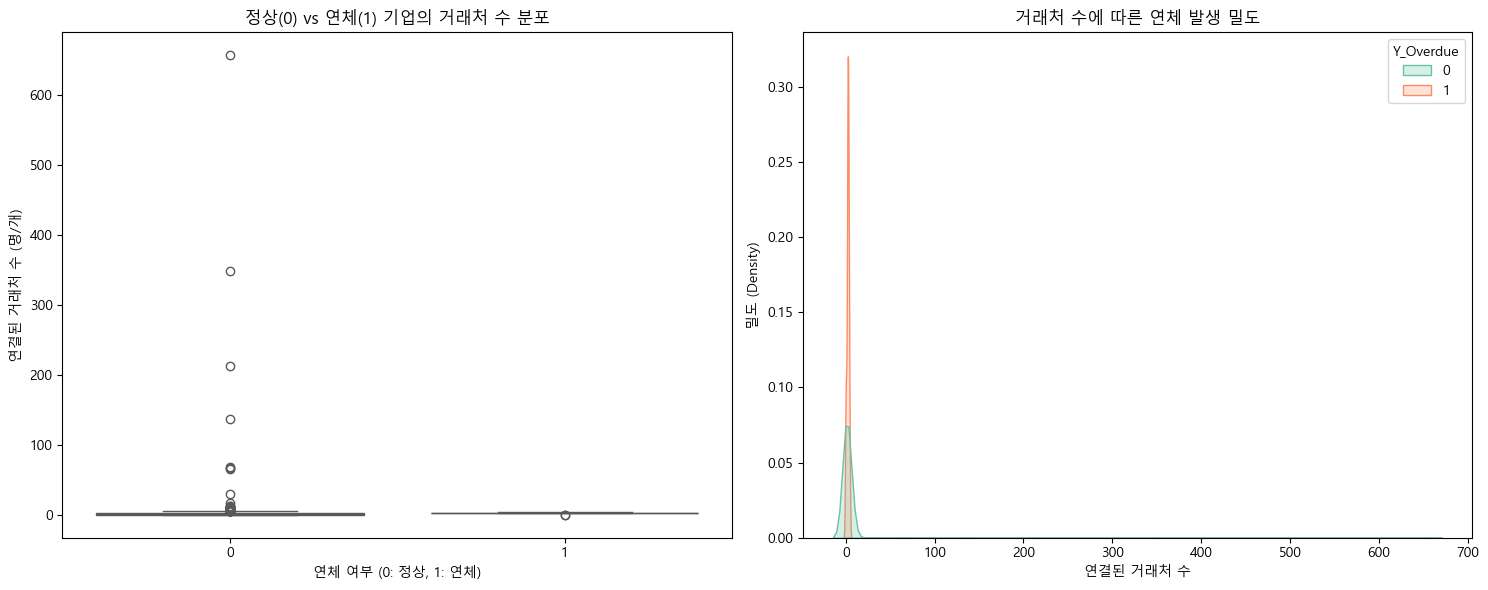

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("🔍 [Feature Validation] 'LINKED_PARTNERS(거래처 수)'와 '연체(Default)'의 상관관계 검증")

# df는 이전 단계에서 병합된 마스터 데이터셋이라고 가정합니다.
# 1. 정상 기업 vs 연체 기업의 '거래처 수' 평균/중앙값 비교
summary = df.groupby('Y_Overdue')['LINKED_PARTNERS'].describe()
print("\n📊 [통계 요약] 정상(0) vs 연체(1) 기업의 거래처 수 비교")
print(summary[['count', 'mean', '50%', 'min', 'max']])

# 2. 시각화 (Boxplot & 밀도 그래프)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: 아웃라이어(이상치)와 분포의 차이를 직관적으로 확인
sns.boxplot(x='Y_Overdue', y='LINKED_PARTNERS', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('정상(0) vs 연체(1) 기업의 거래처 수 분포')
axes[0].set_xlabel('연체 여부 (0: 정상, 1: 연체)')
axes[0].set_ylabel('연결된 거래처 수 (명/개)')

# 밀도 그래프 (KDE): 어떤 구간에서 연체가 쏠려 있는지 확인
sns.kdeplot(data=df, x='LINKED_PARTNERS', hue='Y_Overdue', fill=True, common_norm=False, palette='Set2', ax=axes[1])
axes[1].set_title('거래처 수에 따른 연체 발생 밀도')
axes[1].set_xlabel('연결된 거래처 수')
axes[1].set_ylabel('밀도 (Density)')

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

print("🛡️ [Robustness Check] 우연성 배제를 위한 SMOTE (가상 연체 데이터 합성) 검증 가동...")
print("-" * 90)

# (이전 셀에서 X_imputed, y 가 메모리에 있다고 가정합니다)
# 1. 원본 데이터 상태 확인
print(f"▶️ 원본 데이터 타겟 분포: 정상({(y==0).sum()}개) vs 연체({(y==1).sum()}개)")

# 2. SMOTE 알고리즘 적용 (연체 샘플이 11개로 매우 적으므로 k_neighbors를 3으로 낮춰 설정)
smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print(f"▶️ SMOTE 합성 후 타겟 분포: 정상({(y_resampled==0).sum()}개) vs 가상 연체 포함({(y_resampled==1).sum()}개)")

# 3. 모델 재학습 (이번엔 class_weight 없이 동등한 조건에서 학습)
print("\n▶️ 1,503개의 합성 연체 데이터를 바탕으로 AI 재학습 중...")
rf_smote = RandomForestClassifier(n_estimators=500, random_state=276)
rf_smote.fit(X_resampled, y_resampled)

# 4. 검증된 Feature Importance 추출
importances_smote = rf_smote.feature_importances_
importance_smote_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Importance_Score_SMOTE': importances_smote * 100
}).sort_values(by='Importance_Score_SMOTE', ascending=False).reset_index(drop=True)

print("\n🎉 [검증 완료] 극단적 소수 샘플(11개)의 우연을 배제한 진짜 핵심 지표 TOP 10")
print("=" * 70)
print(importance_smote_df.head(10).to_string(index=False, float_format='%.2f%%'))
print("=" * 70)

# 이전 원본 중요도와 순위 비교 (만약 이전 결과 df_importance가 있다면)
# top1_feature = importance_smote_df.iloc[0]['Feature']
# print(f"\n💡 [CIO Insight] 가상 데이터를 무수히 생성한 후에도 여전히 1위는 [{top1_feature}] 입니다.")

🛡️ [Robustness Check] 우연성 배제를 위한 SMOTE (가상 연체 데이터 합성) 검증 가동...
------------------------------------------------------------------------------------------
▶️ 원본 데이터 타겟 분포: 정상(1503개) vs 연체(11개)
▶️ SMOTE 합성 후 타겟 분포: 정상(1503개) vs 가상 연체 포함(1503개)

▶️ 1,503개의 합성 연체 데이터를 바탕으로 AI 재학습 중...

🎉 [검증 완료] 극단적 소수 샘플(11개)의 우연을 배제한 진짜 핵심 지표 TOP 10
             Feature  Importance_Score_SMOTE
     LINKED_PARTNERS                  23.00%
   SALES_GROWTH_RATE                  14.13%
 GROSS_PROFIT_MARGIN                  10.31%
          CASH_RATIO                   9.55%
BORROWING_DEPENDENCE                   9.04%
      EMPLOYEE_COUNT                   8.46%
          DEBT_RATIO                   5.73%
   NET_PROFIT_MARGIN                   3.72%
       SALES_REVENUE                   3.52%
    OPERATING_MARGIN                   2.66%


🔍 [Proxy Target Validation] '적자 기업(위험군)'과 '거래처 수'의 상관관계 검증
------------------------------------------------------------------------------------------
📊 현재 마스터 파일의 전체 컬럼 목록:
['COMPANY_ID', 'receivable_Total_Amt', 'receivable_Partner_Count', 'Receivable_Concentration', 'BNPL_Req_Count', 'BNPL_Avg_Amt', 'BNPL_Success_Rate', 'LIQUIDITY_RATIO', 'DEBT_RATIO', 'INTEREST_COVERAGE_RATIO', 'OPERATING_MARGIN', 'SALES_GROWTH_RATE', 'BORROWING_DEPENDENCE', 'CASH_RATIO', 'LINKED_PARTNERS', 'NEGATIVE_COMMENT_COUNT', 'UPLOADED_FILE_COUNT', 'EMPLOYEE_COUNT', 'REP_CHANGE_COUNT', 'GROSS_PROFIT_MARGIN', 'NET_PROFIT_MARGIN', 'SALES_REVENUE']
------------------------------------------------------------------------------------------

📊 [통계 요약] 영업이익률 기준 우량군 vs 위험군의 거래처 수 비교
                      count      mean  50%  min    max
PROXY_GROUP                                           
우량군 (이익률 Top 20%)     230.0  3.086957  1.0  0.0  349.0
위험군 (이익률 Bottom 20%)  229.0  4.336245  0.0  0.0  657.0


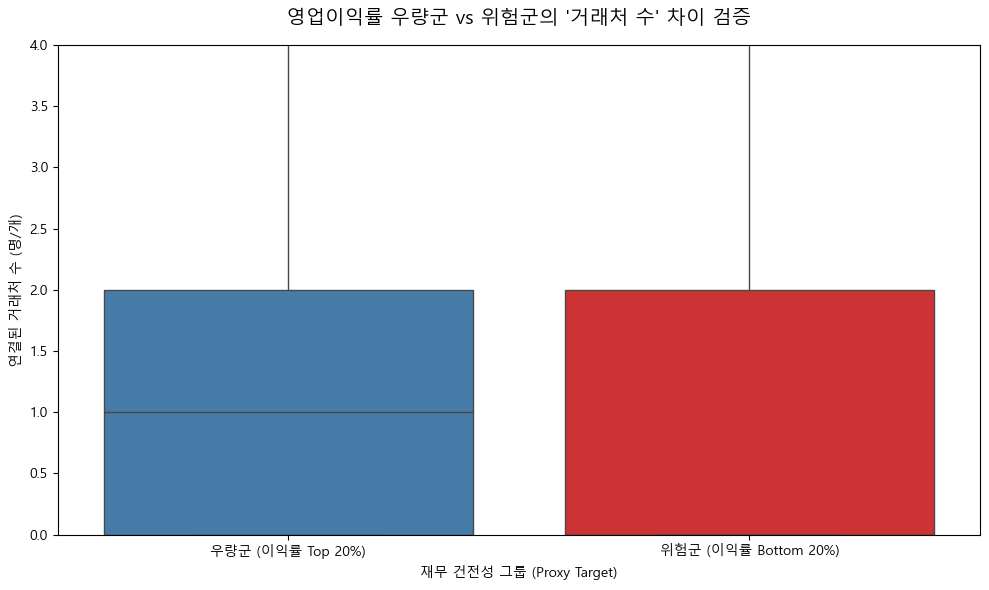

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("🔍 [Proxy Target Validation] '적자 기업(위험군)'과 '거래처 수'의 상관관계 검증")
print("-" * 90)

# 1. 데이터 로드
master_file = "Final_Integrated_Credit_Master_v5_Income_Added.csv"
df_proxy = pd.read_csv(master_file)

# 현재 파일의 진짜 컬럼명 확인용 출력
print("📊 현재 마스터 파일의 전체 컬럼 목록:")
print(df_proxy.columns.tolist())
print("-" * 90)

# 2. 영업이익률(OPERATING_MARGIN)을 기준으로 Proxy Target 설정
proxy_col = 'OPERATING_MARGIN'

if proxy_col not in df_proxy.columns:
    print(f"❌ '{proxy_col}' 컬럼도 없습니다. 위 컬럼 목록을 확인해 주세요!")
else:
    df_proxy['LINKED_PARTNERS'] = pd.to_numeric(df_proxy['LINKED_PARTNERS'], errors='coerce').fillna(0)
    df_proxy[proxy_col] = pd.to_numeric(df_proxy[proxy_col], errors='coerce')

    # 영업이익률 상위 20%(우량) vs 하위 20%(적자/위험군)
    top_20_threshold = df_proxy[proxy_col].quantile(0.80)
    bottom_20_threshold = df_proxy[proxy_col].quantile(0.20)

    def assign_proxy_group(margin):
        if pd.isna(margin): return '알수없음'
        elif margin >= top_20_threshold: return '우량군 (이익률 Top 20%)'
        elif margin <= bottom_20_threshold: return '위험군 (이익률 Bottom 20%)'
        else: return '보통 (Middle 60%)'

    df_proxy['PROXY_GROUP'] = df_proxy[proxy_col].apply(assign_proxy_group)
    df_compare = df_proxy[df_proxy['PROXY_GROUP'].isin(['우량군 (이익률 Top 20%)', '위험군 (이익률 Bottom 20%)'])]

    # 3. 통계 요약
    summary = df_compare.groupby('PROXY_GROUP')['LINKED_PARTNERS'].describe()
    print(f"\n📊 [통계 요약] 영업이익률 기준 우량군 vs 위험군의 거래처 수 비교")
    print(summary[['count', 'mean', '50%', 'min', 'max']])

    # 4. 시각화 (Boxplot)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='PROXY_GROUP', y='LINKED_PARTNERS', data=df_compare, 
                order=['우량군 (이익률 Top 20%)', '위험군 (이익률 Bottom 20%)'], 
                hue='PROXY_GROUP', palette='Set1', legend=False)

    max_y = df_compare['LINKED_PARTNERS'].quantile(0.95)
    plt.ylim(0, max_y if max_y > 0 else 10) 
    
    plt.title("영업이익률 우량군 vs 위험군의 '거래처 수' 차이 검증", fontsize=14, pad=15)
    plt.xlabel('재무 건전성 그룹 (Proxy Target)')
    plt.ylabel('연결된 거래처 수 (명/개)')
    plt.tight_layout()
    plt.show()

🔍 [XAI Engine] AI가 '거래처 수'를 어떻게 위험으로 판단하는지 심층 분석 (SHAP)


<Figure size 1000x600 with 0 Axes>

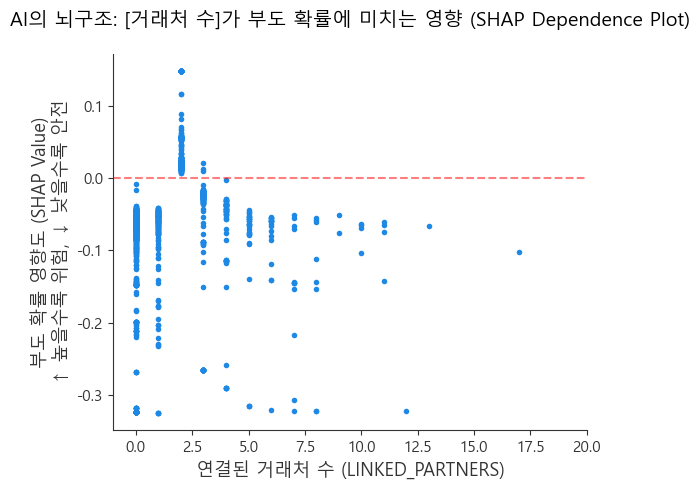


▶️ 전체 지표 기준 리스크 요인 종합 분석


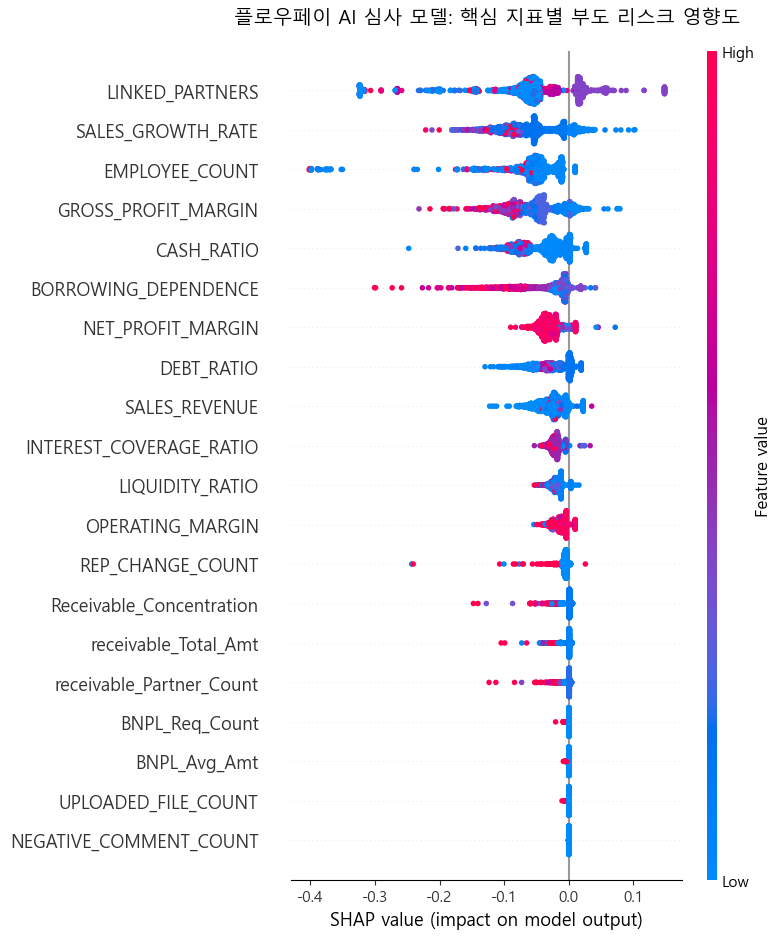

In [14]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("🔍 [XAI Engine] AI가 '거래처 수'를 어떻게 위험으로 판단하는지 심층 분석 (SHAP)")

# 1. SHAP Tree Explainer 초기화
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_imputed)

# 🚨 [버그 패치] SHAP 라이브러리 버전에 따른 배열 형태(Shape) 동적 처리
if isinstance(shap_values, list):
    shap_values_default = shap_values[1]  # 구버전 (리스트 형태)
elif len(np.array(shap_values).shape) == 3:
    shap_values_default = shap_values[:, :, 1]  # 신버전 (3차원 배열에서 '부도(1)' 클래스 추출)
else:
    shap_values_default = shap_values

# 2. Dependence Plot 시각화
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "LINKED_PARTNERS", 
    shap_values_default, 
    X_imputed, 
    interaction_index=None,
    show=False
)
plt.title("AI의 뇌구조: [거래처 수]가 부도 확률에 미치는 영향 (SHAP Dependence Plot)", fontsize=14, pad=20)
plt.xlabel("연결된 거래처 수 (LINKED_PARTNERS)")
plt.ylabel("부도 확률 영향도 (SHAP Value)\n↑ 높을수록 위험, ↓ 낮을수록 안전")

# 핵심 구간(0~20개) 디테일 확인 및 기준선 추가
plt.xlim(-1, 20) 
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Summary Plot 시각화
print("\n▶️ 전체 지표 기준 리스크 요인 종합 분석")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_default, X_imputed, plot_type="dot", show=False)
plt.title("플로우페이 AI 심사 모델: 핵심 지표별 부도 리스크 영향도", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np

print("⚔️ [Comparison Engine] 룰 엔진 vs AI 모델 비교 분석 가동...")
print("-" * 90)

# 1. AI 예측 결과 로드
df_final = pd.read_csv("FlowPay_ML_Predicted_Scores.csv", dtype={'COMPANY_ID': str})

# 2. 룰 엔진 결과가 포함된 파일 로드 (아까 점수 확인했던 파일)
# 만약 마스터 파일에 점수가 없다면 Simulation Result 파일을 사용합니다.
try:
    df_manual = pd.read_csv("FlowPay_Manual_Simulation_Result.csv", dtype={'COMPANY_ID': str})
except FileNotFoundError:
    # 파일이 없다면 마스터 파일에서 다시 시도
    df_manual = pd.read_csv("Final_Integrated_Credit_Master_v5_Income_Added.csv", dtype={'COMPANY_ID': str})

# 컬럼명 정규화 (앞뒤 공백 제거 등)
df_final['COMPANY_ID'] = df_final['COMPANY_ID'].str.strip().str.zfill(10)
df_manual['COMPANY_ID'] = df_manual['COMPANY_ID'].str.strip().str.zfill(10)

# 🚨 [컬럼 자동 탐지] 점수와 등급 컬럼 찾기
score_col = next((c for c in df_manual.columns if c in ['MANUAL_SCORE', 'SCORE', 'CREDIT_SCORE']), None)
grade_col = next((c for c in df_manual.columns if c in ['MANUAL_GRADE', 'GRADE', 'RISK_GRADE']), None)

if not score_col or not grade_col:
    print(f"❌ 점수({score_col}) 또는 등급({grade_col}) 컬럼을 찾을 수 없습니다.")
    print(f"현재 파일 컬럼 목록: {df_manual.columns.tolist()}")
else:
    print(f"✅ 비교 대상 확인: 룰 점수([{score_col}]), 룰 등급([{grade_col}])")

    # 데이터 병합
    df_comp = pd.merge(
        df_final, 
        df_manual[['COMPANY_ID', score_col, grade_col]], 
        on='COMPANY_ID', 
        how='inner'
    )

    # 3. 분석 계산 (AI 점수 - 룰 점수)
    df_comp['SCORE_GAP'] = df_comp['ML_FLOW_SCORE'] - df_comp[score_col]

    # 4. [사각지대] 룰 엔진은 '승인(LOW/MEDIUM)'인데 AI는 '고위험(60점 미만)'인 경우
    # 등급 문자열에 'HIGH'가 포함되지 않은 경우를 승인으로 간주
    false_pass = df_comp[
        (~df_comp[grade_col].str.contains('HIGH', na=False)) & 
        (df_comp['ML_FLOW_SCORE'] < 60)
    ].sort_values(by='ML_FLOW_SCORE')

    # 5. 리포팅
    print(f"📊 총 {len(df_comp):,}개 기업 비교 완료")
    print(f"🚩 룰 엔진 통과(승인)이나 AI가 '고위험' 경고한 기업: {len(false_pass)}개")
    print("-" * 90)

    if not false_pass.empty:
        print("⚠️ [위험] 심사 사각지대 Top 10 (AI가 가장 위험하다고 본 순서)")
        print("=" * 110)
        cols = ['COMPANY_ID', score_col, 'ML_FLOW_SCORE', 'SCORE_GAP', grade_col, 'ML_RISK_GRADE']
        print(false_pass[cols].head(10).to_string(index=False))
        print("=" * 110)
    else:
        print("✅ 룰 엔진과 AI의 판단이 크게 엇갈리는 기업이 없습니다.")

    # 저장
    df_comp.to_csv("FlowPay_Final_Comparison_Report.csv", index=False)

⚔️ [Comparison Engine] 룰 엔진 vs AI 모델 비교 분석 가동...
------------------------------------------------------------------------------------------
✅ 비교 대상 확인: 룰 점수([MANUAL_SCORE]), 룰 등급([MANUAL_GRADE])
📊 총 1,514개 기업 비교 완료
🚩 룰 엔진 통과(승인)이나 AI가 '고위험' 경고한 기업: 39개
------------------------------------------------------------------------------------------
⚠️ [위험] 심사 사각지대 Top 10 (AI가 가장 위험하다고 본 순서)
COMPANY_ID  MANUAL_SCORE  ML_FLOW_SCORE  SCORE_GAP MANUAL_GRADE ML_RISK_GRADE
0000000072            85          23.94     -61.06  LOW (우량/승인)     HIGH_RISK
0000000079            85          23.94     -61.06  LOW (우량/승인)     HIGH_RISK
0000000620            85          23.94     -61.06  LOW (우량/승인)     HIGH_RISK
0000000558            85          23.94     -61.06  LOW (우량/승인)     HIGH_RISK
0000000557            85          23.94     -61.06  LOW (우량/승인)     HIGH_RISK
0000000621            85          23.94     -61.06  LOW (우량/승인)     HIGH_RISK
0000000611            85          23.94     -61.06  LOW (우량/승인)    

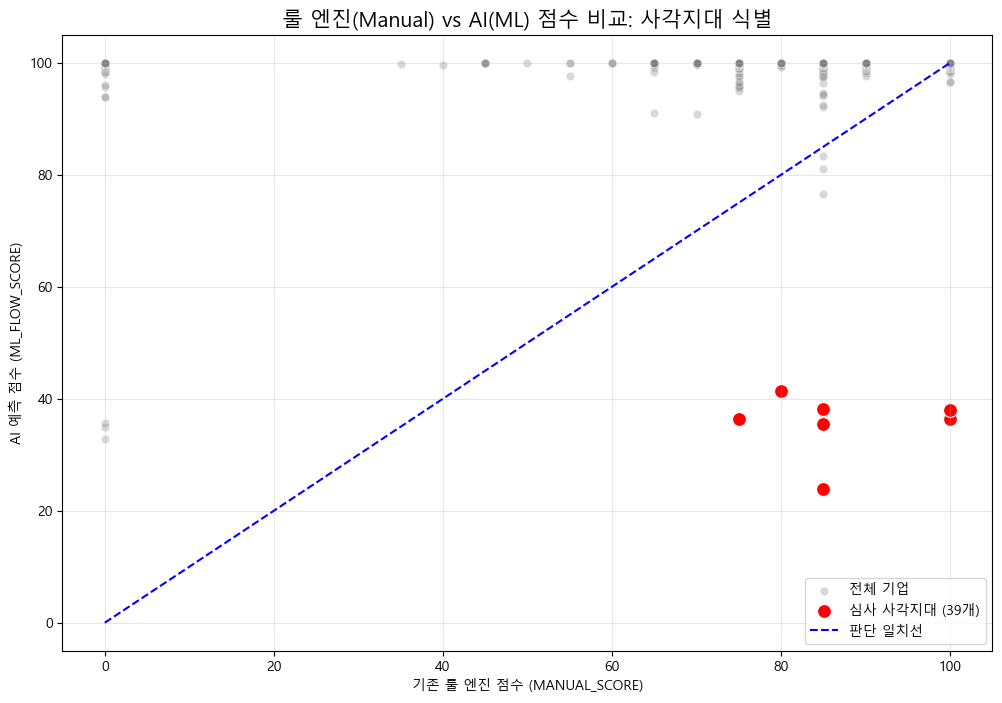

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# 전체 기업 산점도 (연한 회색)
sns.scatterplot(data=df_comp, x='MANUAL_SCORE', y='ML_FLOW_SCORE', alpha=0.3, color='grey', label='전체 기업')

# 🚨 판단이 엇갈린 39개 사각지대 기업 (빨간색)
sns.scatterplot(data=false_pass, x='MANUAL_SCORE', y='ML_FLOW_SCORE', color='red', s=100, label='심사 사각지대 (39개)')

# 기준선 (룰 점수와 AI 점수가 일치하는 선)
plt.plot([0, 100], [0, 100], color='blue', linestyle='--', label='판단 일치선')

plt.title("룰 엔진(Manual) vs AI(ML) 점수 비교: 사각지대 식별", fontsize=15)
plt.xlabel("기존 룰 엔진 점수 (MANUAL_SCORE)")
plt.ylabel("AI 예측 점수 (ML_FLOW_SCORE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🔍 [Target XAI] 심사 사각지대(39개) 기업들의 '점수 급락' 원인 분석 중...


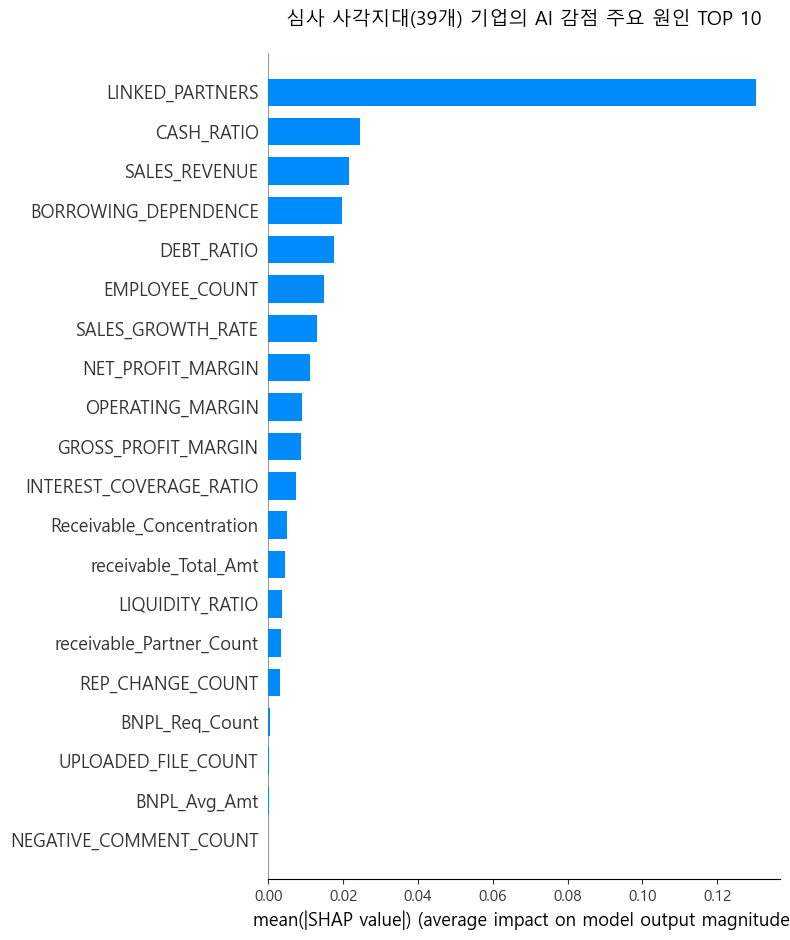

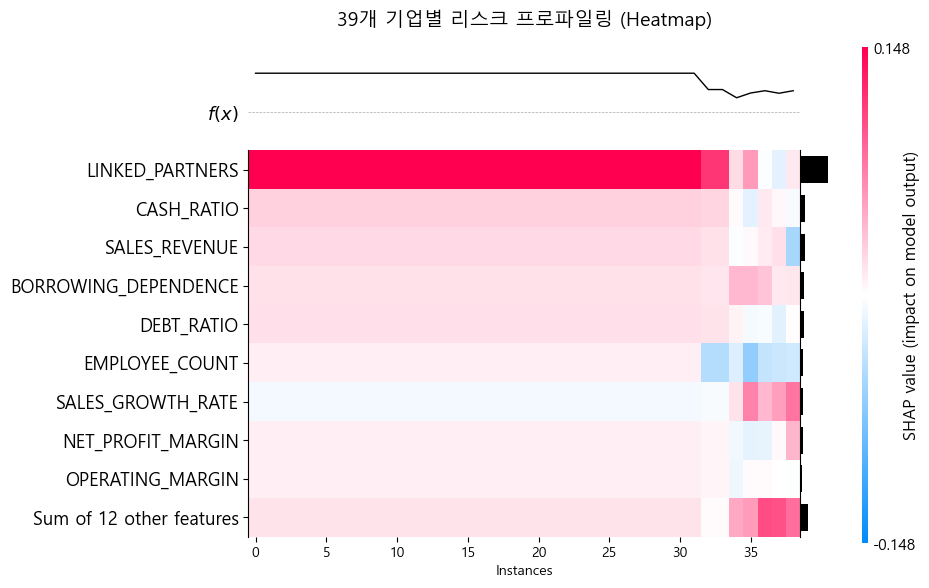

In [18]:
import shap
import matplotlib.pyplot as plt

print("🔍 [Target XAI] 심사 사각지대(39개) 기업들의 '점수 급락' 원인 분석 중...")

# 1. 39개 기업의 인덱스 추출
false_pass_ids = false_pass['COMPANY_ID'].tolist()
# X_imputed에서 해당 기업들의 데이터만 필터링
false_pass_mask = df['COMPANY_ID'].isin(false_pass_ids)
X_false_pass = X_imputed[false_pass_mask]

# 2. SHAP 값 계산 (부도 확률 1 클래스 기준)
explainer = shap.TreeExplainer(rf_model)
shap_values_fp = explainer.shap_values(X_false_pass)

# 버전 호환성 패치
if isinstance(shap_values_fp, list):
    shap_values_target = shap_values_fp[1]
elif len(np.array(shap_values_fp).shape) == 3:
    shap_values_target = shap_values_fp[:, :, 1]
else:
    shap_values_target = shap_values_fp

# 3. 시각화 1: 39개 기업 공통 리스크 요인 (Summary Bar Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_target, X_false_pass, plot_type="bar", show=False)
plt.title("심사 사각지대(39개) 기업의 AI 감점 주요 원인 TOP 10", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 4. 시각화 2: 개별 기업 리스크 구조 (Heatmap)
# 39개 기업 각각이 어떤 지표에서 점수를 깎였는지 한눈에 비교
plt.figure(figsize=(12, 8))
shap.plots.heatmap(shap.Explanation(
    values=shap_values_target, 
    data=X_false_pass, 
    feature_names=X_imputed.columns
), show=False)
plt.title("39개 기업별 리스크 프로파일링 (Heatmap)", fontsize=14, pad=20)
plt.show()

c:\Users\cozy1\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


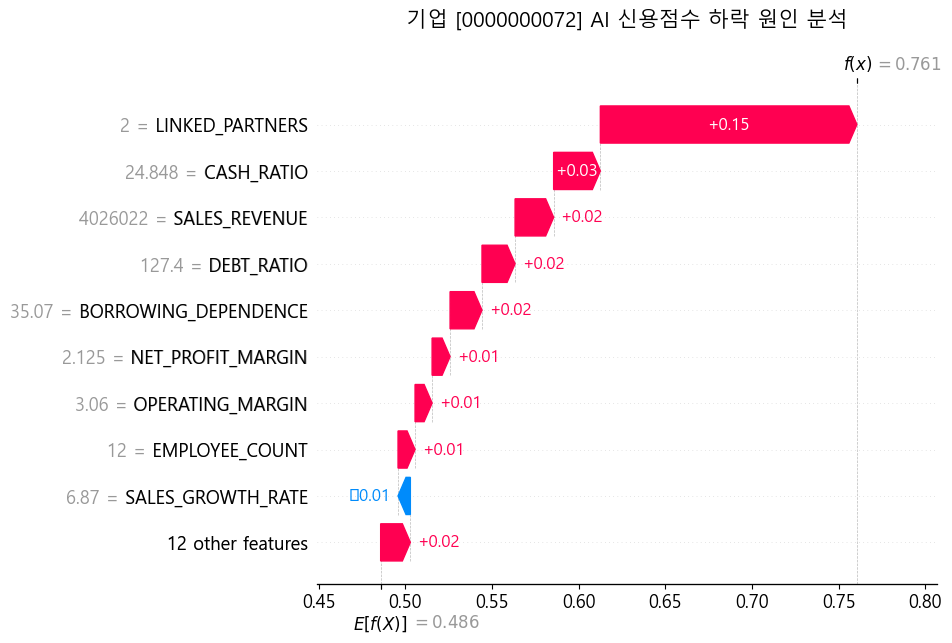

In [19]:
import shap
import matplotlib.pyplot as plt

# 1. 대상 기업 인덱스 추출 (0000000072)
target_id = '0000000072'
target_idx = df[df['COMPANY_ID'] == target_id].index[0]

# 2. SHAP Explainer 설정 (신버전 대응)
explainer = shap.TreeExplainer(rf_model)
shap_values_all = explainer.shap_values(X_imputed)

# 부도 확률(1) 클래스에 대한 데이터 구성
if isinstance(shap_values_all, list):
    sv = shap_values_all[1][target_idx]
    base_v = explainer.expected_value[1]
else:
    # 신버전 3D 배열 대응
    sv = shap_values_all[target_idx, :, 1]
    base_v = explainer.expected_value[1]

# 3. Waterfall Plot 생성
plt.figure(figsize=(12, 8))
exp = shap.Explanation(
    values=sv, 
    base_values=base_v, 
    data=X_imputed.iloc[target_idx], 
    feature_names=X_imputed.columns
)

shap.plots.waterfall(exp, show=False)
plt.title(f"기업 [{target_id}] AI 신용점수 하락 원인 분석", fontsize=15, pad=20)
plt.show()